In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# save the data so that we don't have to run simulation again
data = np.load('slinky_2D_data_raw.npz')
qs = data['qs']
Fs_arr = data['F']
t_arr = data['t']

n_nodes = (qs.shape[1] +1)//4

(90, 407)
(90, 407)


In [ ]:
## filter
first_idx_of_interest = 1 # ignore the first 100 frames where the F is loggesd as zeros
last_idx_of_interest = 10 # ignore the last 100 frames where the force decreases
# filter all force qs to last_idx_of_interest
q_filtered = qs[first_idx_of_interest:-last_idx_of_interest, :]
F_filtered = Fs_arr[first_idx_of_interest:-last_idx_of_interest, :]
t_filtered = t_arr[first_idx_of_interest:-last_idx_of_interest]

print(q_filtered.shape)
print(F_filtered.shape)


In [ ]:
num_t = q_filtered.shape[0]

# original qs format:
# [all node positions, all thetas]
# = [x0,y0,z0, x1,y1,z1, ..., x_{N-1},y_{N-1},z_{N-1}, theta0,...,theta_{N-2}]

positions = q_filtered[:, :3*n_nodes] # shape (num_t, 3*n_nodes)
positions_reshaped = positions.reshape(num_t, n_nodes, 3)

# first and last nodes
node0 = positions_reshaped[:, 0, :]
node_last = positions_reshaped[:, -1, :]

# centroid of all original nodes
centroid = np.mean(positions_reshaped, axis=1)

# reduced state:
# [x0,y0,z0,theta0, xc,yc,zc,theta1, xlast,ylast,zlast]
qs_to_train = np.zeros((num_t, 11))
qs_to_train[:, 0:3] = node0
qs_to_train[:, 3] = 0.0
qs_to_train[:, 4] = centroid[:, 0] # x of centroid
## y is ignored since it's always zero in 2D
qs_to_train[:, 6] = centroid[:, 2] # z of centroid
qs_to_train[:, 7] = 0.0
qs_to_train[:, 8:11] = node_last

# BC dofs in reduced state
idx_b = [0, 1, 2, 3, 7, 8, 9, 10]

# BC values over time
xb = np.zeros((num_t, len(idx_b)))
xb[:, 5:8] = node_last

# example force target: x,z force on node 0 with zero y
F_train = np.column_stack([
    F_filtered[:, 0],
    np.zeros(num_t),
    F_filtered[:, 2],
])

# add time (lambdas array) to the training data
lambdas = np.linspace(0, 1, num_t)


In [ ]:
# add a preceding dimension to indicate that we have one trajectory
qs_to_train = qs_to_train[np.newaxis, :, :]
F_train = F_train[np.newaxis, :, :]
xb = xb[np.newaxis, :, :]
lambdas = lambdas[np.newaxis, :]
valid = np.full((qs_to_train.shape[0], qs_to_train.shape[1]), True)

initial_last_node_x = q_filtered[0, 3*n_nodes - 3]
final_last_node_x = q_filtered[-1, 3*n_nodes - 3]

print(f"Initial last node x: {initial_last_node_x:.4f} m")
print(f"Final last node x: {final_last_node_x:.4f} m")
print(qs_to_train.shape)
print(valid.shape)

np.savez('slinky_2D_train_data_settled_start.npz', qs=qs_to_train, F=F_train, xb=xb, idx_b=idx_b, lambdas=lambdas, valid=valid)


Initial last node x: 0.2100 m
Final last node x: 1.1000 m
(1, 90, 11)
(1, 90)


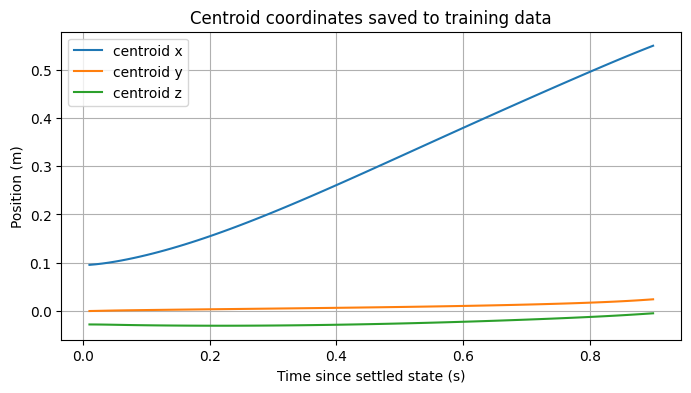

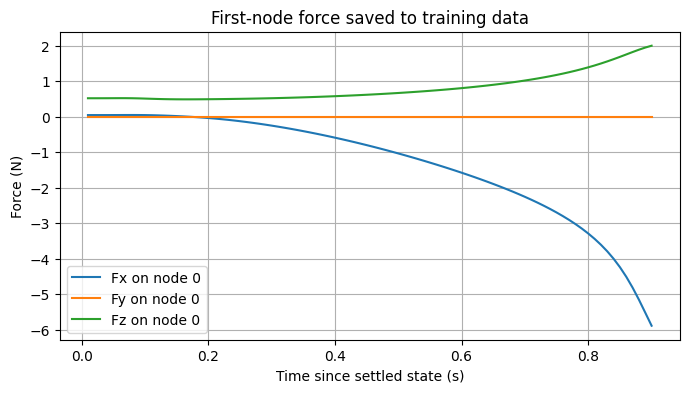

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(t_filtered, centroid[:, 0], label='centroid x')
plt.plot(t_filtered, centroid[:, 1], label='centroid y')
plt.plot(t_filtered, centroid[:, 2], label='centroid z')
plt.xlabel('Time since settled state (s)')
plt.ylabel('Position (m)')
plt.title('Centroid coordinates saved to training data')
plt.grid(True)
plt.legend()

plt.figure(figsize=(8, 4))
plt.plot(t_filtered, F_filtered[:, 0], label='Fx on node 0')
plt.plot(t_filtered, np.zeros_like(t_filtered), label='Fy on node 0')
plt.plot(t_filtered, F_filtered[:, 2], label='Fz on node 0')
plt.xlabel('Time since settled state (s)')
plt.ylabel('Force (N)')
plt.title('First-node force saved to training data')
plt.grid(True)
plt.legend()


In [ ]:
# additional centerline point between node0 and the overall centroid:
# centroid of the first half of the nodes
half_idx = n_nodes // 2
centroid_first_half = np.mean(positions_reshaped[:, :half_idx, :], axis=1)

print(f"First-half node range: 0 .. {half_idx - 1}  ({half_idx} nodes)")
print(f"centroid_first_half shape: {centroid_first_half.shape}")
print(f"centroid_first_half at t=0: {centroid_first_half[0]}")
print(f"centroid_first_half at t=-1: {centroid_first_half[-1]}")


In [ ]:
# additional centerline point between the overall centroid and node_last:
# centroid of the second half of the nodes
centroid_second_half = np.mean(positions_reshaped[:, half_idx:, :], axis=1)

print(f"Second-half node range: {half_idx} .. {n_nodes - 1}  ({n_nodes - half_idx} nodes)")
print(f"centroid_second_half shape: {centroid_second_half.shape}")
print(f"centroid_second_half at t=0: {centroid_second_half[0]}")
print(f"centroid_second_half at t=-1: {centroid_second_half[-1]}")


In [ ]:
# 5-noded centerline state:
# [node0, centroid_first_half, centroid, centroid_second_half, node_last]
# layout (19 dofs):
#   [x0,y0,z0, theta0,
#    xc1,yc1,zc1, theta1,
#    xc, yc, zc, theta2,
#    xc2,yc2,zc2, theta3,
#    xlast,ylast,zlast]

qs_to_train_5 = np.zeros((num_t, 19))

# node0
qs_to_train_5[:, 0:3] = node0
qs_to_train_5[:, 3]   = 0.0

# centroid of first half (y stays 0 -- 2D)
qs_to_train_5[:, 4]   = centroid_first_half[:, 0]
qs_to_train_5[:, 6]   = centroid_first_half[:, 2]
qs_to_train_5[:, 7]   = 0.0

# overall centroid
qs_to_train_5[:, 8]   = centroid[:, 0]
qs_to_train_5[:, 10]  = centroid[:, 2]
qs_to_train_5[:, 11]  = 0.0

# centroid of second half
qs_to_train_5[:, 12]  = centroid_second_half[:, 0]
qs_to_train_5[:, 14]  = centroid_second_half[:, 2]
qs_to_train_5[:, 15]  = 0.0

# node_last
qs_to_train_5[:, 16:19] = node_last

# BC dofs: node0 position + its trailing theta, node_last position + its preceding theta
idx_b_5 = [0, 1, 2, 3, 15, 16, 17, 18]

xb_5 = np.zeros((num_t, len(idx_b_5)))
xb_5[:, 5:8] = node_last  # last three BC columns carry node_last position

# force target: same as 3-noded version (force on node0, zero y)
F_train_5 = np.column_stack([
    F_filtered[:, 0],
    np.zeros(num_t),
    F_filtered[:, 2],
])

lambdas_5 = np.linspace(0, 1, num_t)

# add trajectory dim
qs_to_train_5 = qs_to_train_5[np.newaxis, :, :]
F_train_5     = F_train_5[np.newaxis, :, :]
xb_5          = xb_5[np.newaxis, :, :]
lambdas_5     = lambdas_5[np.newaxis, :]
valid_5       = np.full((qs_to_train_5.shape[0], qs_to_train_5.shape[1]), True)

print(f"qs_to_train_5 shape: {qs_to_train_5.shape}")
print(f"xb_5 shape:          {xb_5.shape}")
print(f"idx_b_5:             {idx_b_5}")

np.savez(
    'slinky_2D_train_data_settled_start_5_noded.npz',
    qs=qs_to_train_5,
    F=F_train_5,
    xb=xb_5,
    idx_b=idx_b_5,
    lambdas=lambdas_5,
    valid=valid_5,
)
